# results: Fairness over time across all models
- combine all models into one df
- add a size variable
- make combined plots
- test whether size is related to accuracy/fairness
- test whether the time trend differs by size

OBS. the biggest models are mostly newer, so if bigger models look more accurate/stable, it might be because they are bigger, but it might also be because they are newer, or both

To assess whether model scale is associated with performance, we combined all evaluated models into a single dataset and added a size variable, both as categorical size groups and, where possible, as approximate parameter count. We then analyzed the relationship between size, year, accuracy, and fairness using descriptive plots and regression models. In particular, we estimated models of the form metric ~ year + size and metric ~ year * size in order to distinguish overall size effects from differences in time trends across model scales.

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr
import statsmodels.formula.api as smf

In [2]:
FAIR_ABS = "avg_minmax_abs"
FAIR_REL = "avg_minmax_rel"
FAIR_VAR = "avg_var"

In [3]:
# helper functions
def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}


def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]

    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"],
        out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"],
        out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"],
        out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"],
        out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"],
        out["pos_rate_var_recalc"],
        out["fpr_var_recalc"],
        out["fnr_var_recalc"]
    ]))
    return out


def load_result_folder(out_dir, size_group):
    summary_csv = os.path.join(out_dir, "summary_all_models.csv")
    groups_csv = os.path.join(out_dir, "groups_all_models.csv")

    df_sum = pd.read_csv(summary_csv).sort_values(["year", "model_id"]).reset_index(drop=True)
    df_groups = pd.read_csv(groups_csv).sort_values(["year", "model_id", "group"]).reset_index(drop=True)

    recalc_rows = []
    for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
        row = {"year": int(year), "model_id": str(model_id)}
        row.update(fairness_from_groups(df_gm))
        recalc_rows.append(row)

    df_recalc = pd.DataFrame(recalc_rows)

    df = (
        df_sum
        .merge(df_recalc, on=["year", "model_id"], how="left")
        .sort_values(["year", "model_id"])
        .reset_index(drop=True)
    )

    df["size_group"] = size_group
    return df


In [4]:
# loading dfs and combining
df_3b = load_result_folder("results_fairness_over_time", "3B")
df_6_8b = load_result_folder("results_fairness_over_time_6to8b", "6-8B")
df_27_34b = load_result_folder("results_fairness_over_time_27to34b", "27-34B")

df_all = pd.concat([df_3b, df_6_8b, df_27_34b], ignore_index=True)

# keep exclusions
df_all = df_all[df_all["model_id"] != "stabilityai/stablelm-base-alpha-7b-v2"].copy()
df_all = df_all[df_all["model_id"] != "tiiuae/Falcon-H1-34B-Base"].copy()

df_all["fairness"] = df_all["avg_minmax_abs_recalc"]
# centering the year variable
df_all["year_c"] = df_all["year"] - df_all["year"].mean()

df_all[["year", "model_id", "size_group", "test_acc", "fairness"]].head()


,year,model_id,size_group,test_acc,fairness
0,2021,EleutherAI/gpt-neo-2.7B,3B,0.792,0.161069
1,2021,facebook/xglm-2.9B,3B,0.776,0.139984
2,2022,EleutherAI/pythia-2.8b-deduped-v0,3B,0.808,0.175970
3,2022,EleutherAI/pythia-2.8b-v0,3B,0.806,0.281412
4,2022,Salesforce/codegen-2B-multi,3B,0.770,0.248553


### combined scatterplots for all models

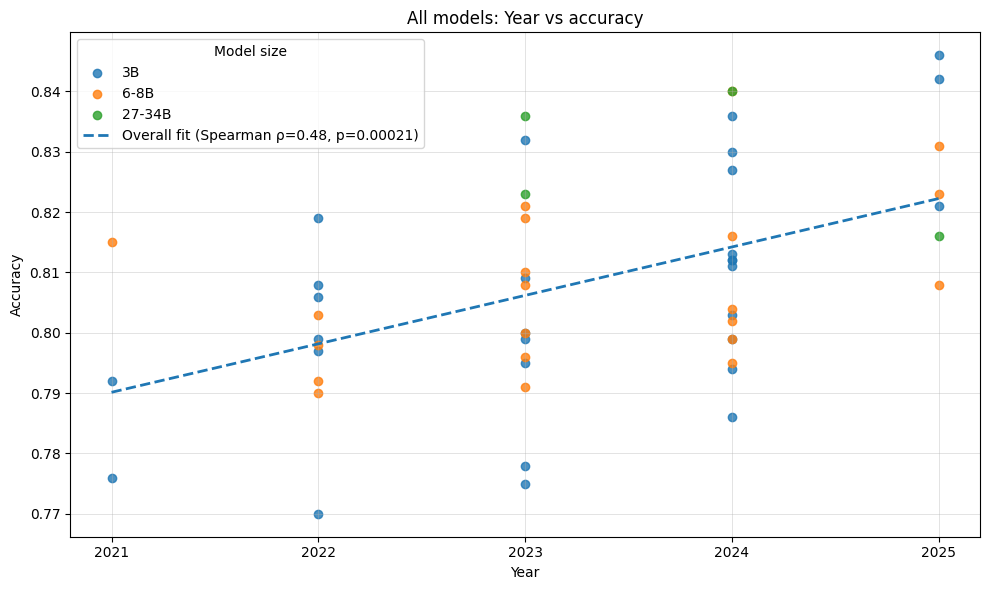

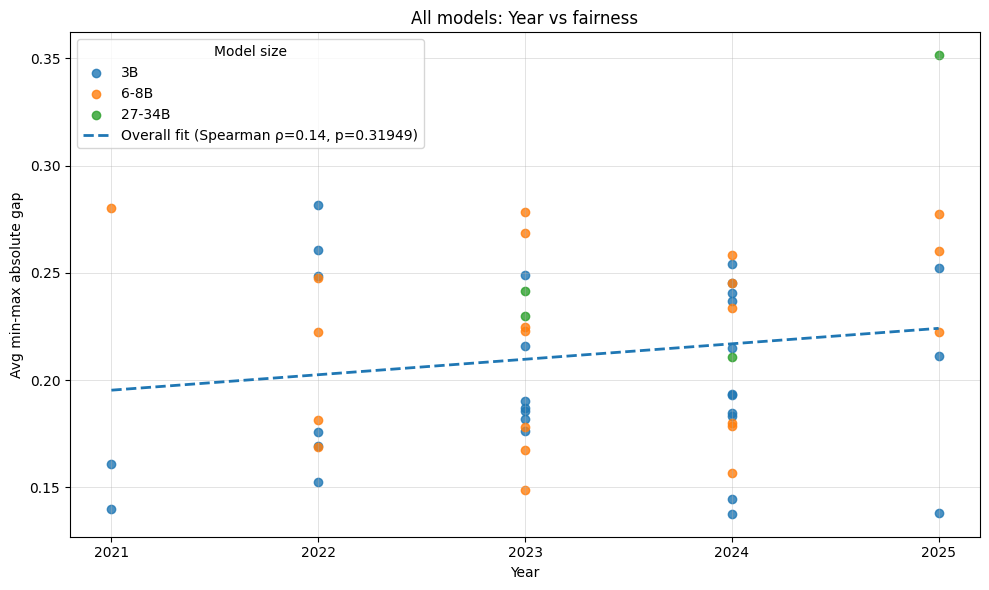

In [5]:
def scatter_by_size(df, xcol, ycol, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # scatter points by size group
    for size_group, sub in df.groupby("size_group", sort=False):
        sub = sub[[xcol, ycol]].dropna()
        ax.scatter(sub[xcol], sub[ycol], label=size_group, alpha=0.8)

    # overall Spearman correlation
    sub_all = df[[xcol, ycol]].dropna()
    if len(sub_all) >= 2 and sub_all[xcol].nunique() >= 2 and sub_all[ycol].nunique() >= 2:
        rho, pval = spearmanr(sub_all[xcol], sub_all[ycol])

        # one overall linear fit line
        z = np.polyfit(sub_all[xcol], sub_all[ycol], 1)
        x_line = np.linspace(sub_all[xcol].min(), sub_all[xcol].max(), 100)
        y_line = np.polyval(z, x_line)
        ax.plot(
            x_line, y_line,
            linestyle="--",
            linewidth=2,
            label=f"Overall fit (Spearman ρ={rho:.2f}, p={pval:.5f})"
        )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.legend(title="Model size")
    plt.tight_layout()
    plt.show()

scatter_by_size(df_all, "year", "test_acc", "All models: Year vs accuracy", "Accuracy")
scatter_by_size(df_all, "year", "fairness", "All models: Year vs fairness", "Avg min-max absolute gap")

In [6]:
# year-level summary table across all models
from scipy.stats import t

def mean_ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()

    if n < 2:
        return pd.Series({
            "mean": mean,
            "std": np.nan,
            "se": np.nan,
            "ci95_low": np.nan,
            "ci95_high": np.nan
        })

    std = x.std(ddof=1)
    se = std / np.sqrt(n)
    tcrit = t.ppf(0.975, df=n-1)

    return pd.Series({
        "mean": mean,
        "std": std,
        "se": se,
        "ci95_low": mean - tcrit * se,
        "ci95_high": mean + tcrit * se
    })

acc_summary = (
    df_all.groupby("year")["test_acc"]
    .apply(mean_ci95)
    .unstack()
    .add_prefix("acc_")
)

fair_summary = (
    df_all.groupby("year")["fairness"]
    .apply(mean_ci95)
    .unstack()
    .add_prefix("fair_")
)

n_summary = (
    df_all.groupby("year")
    .agg(n_models=("model_id", "count"))
)

year_summary_ci = (
    n_summary
    .join(acc_summary)
    .join(fair_summary)
    .reset_index()
    .sort_values("year")
)

year_summary_ci.round(4)

,year,n_models,acc_mean,acc_std,acc_se,acc_ci95_low,acc_ci95_high,fair_mean,fair_std,fair_se,fair_ci95_low,fair_ci95_high
0,2021,3,0.7943,0.0196,0.0113,0.7456,0.8430,0.1938,0.0757,0.0437,0.0058,0.3818
1,2022,10,0.7982,0.0130,0.0041,0.7889,0.8075,0.2109,0.0463,0.0147,0.1777,0.2440
2,2023,16,0.8058,0.0175,0.0044,0.7964,0.8151,0.2091,0.0378,0.0095,0.1890,0.2293
3,2024,18,0.8122,0.0164,0.0039,0.8040,0.8203,0.2051,0.0381,0.0090,0.1861,0.2240
4,2025,7,0.8267,0.0138,0.0052,0.8140,0.8394,0.2447,0.0655,0.0248,0.1841,0.3053


In [7]:
# with size group
year_size = (
    df_all.groupby(["size_group", "year"])
    .agg(
        n_models=("model_id", "count"),
        mean_acc=("test_acc", "mean"),
        mean_fair=("fairness", "mean")
    )
    .reset_index()
    .sort_values(["size_group", "year"])
)

year_size.round(4)

,size_group,year,n_models,mean_acc,mean_fair
0,27-34B,2023,2,0.8295,0.2358
1,27-34B,2024,1,0.8400,0.2107
2,27-34B,2025,1,0.8160,0.3514
3,3B,2021,2,0.7840,0.1505
4,3B,2022,6,0.7998,0.2148
5,3B,2023,7,0.7983,0.1979
6,3B,2024,11,0.8112,0.2026
7,3B,2025,3,0.8363,0.2004
8,6-8B,2021,1,0.8150,0.2803
9,6-8B,2022,4,0.7958,0.2051


In [8]:
# # correlation on yearly means

# rho_acc_year, p_acc_year = spearmanr(year_summary["year"], year_summary["mean_acc"])
# rho_fair_year, p_fair_year = spearmanr(year_summary["year"], year_summary["mean_fair"])

# print("Year-level Spearman for accuracy:", rho_acc_year, p_acc_year)
# print("Year-level Spearman for fairness:", rho_fair_year, p_fair_year)

### comparing size groups directly (descriptive)

In [9]:
summary_by_size = (
    df_all.groupby("size_group")
    .agg(
        n_models=("model_id", "count"),
        mean_acc=("test_acc", "mean"),
        std_acc=("test_acc", "std"),
        mean_fair=("fairness", "mean"),
        std_fair=("fairness", "std")
    )
    .reset_index()
)

summary_by_size

,size_group,n_models,mean_acc,std_acc,mean_fair,std_fair
0,27-34B,4,0.828750,0.011177,0.258399,0.063301
1,3B,29,0.806448,0.019921,0.200175,0.041404
2,6-8B,21,0.807667,0.013577,0.219140,0.043840


### controlling for year

In [10]:
# year: whether newer models tend to differ
# C(size_group): whether size still matters after accounting for year
# test whether size groups differ from each other after accounting for year
m_acc = smf.ols("test_acc ~ year_c + C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_acc.summary())

                            OLS Regression Results                            
Dep. Variable:               test_acc   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     5.167
Date:                Thu, 28 May 2026   Prob (F-statistic):            0.00345
Time:                        10:47:10   Log-Likelihood:                 151.26
No. Observations:                  54   AIC:                            -294.5
Df Residuals:                      50   BIC:                            -286.6
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.82

In [11]:
m_fair = smf.ols("fairness ~ year_c + C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_fair.summary())

                            OLS Regression Results                            
Dep. Variable:               fairness   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     1.496
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.227
Time:                        10:47:10   Log-Likelihood:                 94.227
No. Observations:                  54   AIC:                            -180.5
Df Residuals:                      50   BIC:                            -172.5
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.25

### stability across years
bigger models seem more similar in accruacy and fairness across years compared to smaller models<br><br>
so, we want to test whether the year effect depends on size

In [12]:
# df_all["year_c"] = df_all["year"] - df_all["year"].mean()
m_acc_inter = smf.ols("test_acc ~ year_c * C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_acc_inter.summary())

                            OLS Regression Results                            
Dep. Variable:               test_acc   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     5.222
Date:                Thu, 28 May 2026   Prob (F-statistic):           0.000660
Time:                        10:47:10   Log-Likelihood:                 153.32
No. Observations:                  54   AIC:                            -294.6
Df Residuals:                      48   BIC:                            -282.7
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [13]:
m_fair_inter = smf.ols("fairness ~ year_c * C(size_group)", data=df_all).fit(cov_type="HC3")
print(m_fair_inter.summary())

                            OLS Regression Results                            
Dep. Variable:               fairness   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                    0.7530
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.588
Time:                        10:47:10   Log-Likelihood:                 95.880
No. Observations:                  54   AIC:                            -179.8
Df Residuals:                      48   BIC:                            -167.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

### how much does models vary across years within each size group?

In [14]:
# yearly means within size group
year_size = (
    df_all.groupby(["size_group", "year"])
    .agg(
        mean_acc=("test_acc", "mean"),
        mean_fair=("fairness", "mean"),
        n=("model_id", "count")
    )
    .reset_index()
)

year_size

,size_group,year,mean_acc,mean_fair,n
0,27-34B,2023,0.829500,0.235771,2
1,27-34B,2024,0.840000,0.210666,1
2,27-34B,2025,0.816000,0.351388,1
3,3B,2021,0.784000,0.150527,2
4,3B,2022,0.799833,0.214767,6
5,3B,2023,0.798286,0.197928,7
6,3B,2024,0.811182,0.202609,11
7,3B,2025,0.836333,0.200409,3
8,6-8B,2021,0.815000,0.280332,1
9,6-8B,2022,0.795750,0.205086,4


In [15]:
# across-year spread of those yearly means
stability_tbl = (
    year_size.groupby("size_group")
    .agg(
        acc_sd_across_years=("mean_acc", "std"),
        fair_sd_across_years=("mean_fair", "std"),
        acc_range_across_years=("mean_acc", lambda x: x.max() - x.min()),
        fair_range_across_years=("mean_fair", lambda x: x.max() - x.min())
    )
    .reset_index()
)

stability_tbl

,size_group,acc_sd_across_years,fair_sd_across_years,acc_range_across_years,fair_range_across_years
0,27-34B,0.012031,0.075056,0.024000,0.140722
1,3B,0.019548,0.024744,0.052333,0.064241
2,6-8B,0.009400,0.033293,0.024917,0.075247


# interpretation of results
### overall year vs accuracy
- scatterplot shows a clear positive trend with a significant p-value: positive association between release year and accuracy across all models
- i.e. newer models tend to be more accurate
- also supported by the regression test_acc ~ year + C(size_group)
    - the coefficient for year is about 0.0083, i.e. accuracy increases by 0.83 percent points per year, on avg, after accounting for size group

### overall year vs fairness
- no clear evidence of a monotonic trend over time in fairness
- not significant coefficient in regression
- i.e. we cannot claim that fairness systematically improves/worsens over time

### size effects
-  descriptive table (mean accuracy): large models are higher in avg accuracy
-  regression (reference group is 27-34B): after controlling for year, 3B models are about 2.1 percent points lower in accuracy than 27-34B and 6-8B are also about 2.1 percent point lower that 27-34B
i.e. larger models (27-34B) are more accurate that smaller size groups after controlling for release year

### fairness by size group
- descriptively: larger modles have the highest fairness gap (suggests that 27-34B are less fair)
- BUT, regression shows that size-group coefficients are not significant and year is not significant
i.e. there is no statistically clear relationship between model size and fairness 

### variation across years and size
- descriptively, 27-34B has the smallest variation across years (for both acc and fair)
- BUT, statistically, we do not have strong evidence fro different time trends by size (not significant interaction terms in regression)
i.e. data visually suggest that larger models may be more stable across years, but it is not stronly supported in the regression interaction analysis

In [16]:
# most fair and unfair models
# lower fairness = more fair
top_k = 5

most_fair = (
    df_all[["year", "model_id", "size_group", "test_acc", "fairness"]]
    .sort_values("fairness", ascending=True)
    .head(top_k)
    .reset_index(drop=True)
)

most_unfair = (
    df_all[["year", "model_id", "size_group", "test_acc", "fairness"]]
    .sort_values("fairness", ascending=False)
    .head(top_k)
    .reset_index(drop=True)
)

print("Most fair models:")
display(most_fair)

print("Most unfair models:")
display(most_unfair)

Most fair models:


,year,model_id,size_group,test_acc,fairness
0,2024,google/recurrentgemma-2b,3B,0.794,0.137717
1,2025,Qwen/Qwen3-4B-Base,3B,0.842,0.137913
2,2021,facebook/xglm-2.9B,3B,0.776,0.139984
3,2024,stabilityai/stable-code-3b,3B,0.786,0.144664
4,2023,EleutherAI/pythia-6.9b,6-8B,0.819,0.148817


Most unfair models:


,year,model_id,size_group,test_acc,fairness
0,2025,marin-community/marin-32b-base,27-34B,0.816,0.351388
1,2022,EleutherAI/pythia-2.8b-v0,3B,0.806,0.281412
2,2021,EleutherAI/gpt-j-6b,6-8B,0.815,0.280332
3,2023,mistralai/Mistral-7B-v0.1,6-8B,0.796,0.278356
4,2025,ibm-granite/granite-3.1-8b-base,6-8B,0.808,0.277535


In [17]:
# within size group
top_k = 3

most_fair_by_size = (
    df_all[["year", "model_id", "size_group", "test_acc", "fairness"]]
    .sort_values(["size_group", "fairness"], ascending=[True, True])
    .groupby("size_group", group_keys=False)
    .head(top_k)
    .reset_index(drop=True)
)

most_unfair_by_size = (
    df_all[["year", "model_id", "size_group", "test_acc", "fairness"]]
    .sort_values(["size_group", "fairness"], ascending=[True, False])
    .groupby("size_group", group_keys=False)
    .head(top_k)
    .reset_index(drop=True)
)

print("Most fair models within each size group:")
display(most_fair_by_size)

print("Most unfair models within each size group:")
display(most_unfair_by_size)

Most fair models within each size group:


,year,model_id,size_group,test_acc,fairness
0,2024,Qwen/Qwen2.5-32B,27-34B,0.840,0.210666
1,2023,codellama/CodeLlama-34b-hf,27-34B,0.823,0.229786
2,2023,01-ai/Yi-34B,27-34B,0.836,0.241756
3,2024,google/recurrentgemma-2b,3B,0.794,0.137717
4,2025,Qwen/Qwen3-4B-Base,3B,0.842,0.137913
5,2021,facebook/xglm-2.9B,3B,0.776,0.139984
6,2023,EleutherAI/pythia-6.9b,6-8B,0.819,0.148817
7,2024,Qwen/Qwen2.5-7B,6-8B,0.840,0.156870
8,2023,tiiuae/falcon-7b,6-8B,0.808,0.167246


Most unfair models within each size group:


,year,model_id,size_group,test_acc,fairness
0,2025,marin-community/marin-32b-base,27-34B,0.816,0.351388
1,2023,01-ai/Yi-34B,27-34B,0.836,0.241756
2,2023,codellama/CodeLlama-34b-hf,27-34B,0.823,0.229786
3,2022,EleutherAI/pythia-2.8b-v0,3B,0.806,0.281412
4,2022,facebook/opt-2.7b,3B,0.797,0.260595
5,2024,meta-llama/Llama-3.2-3B,3B,0.803,0.253981
6,2021,EleutherAI/gpt-j-6b,6-8B,0.815,0.280332
7,2023,mistralai/Mistral-7B-v0.1,6-8B,0.796,0.278356
8,2025,ibm-granite/granite-3.1-8b-base,6-8B,0.808,0.277535
